Sreehari Ramabhadran - 25247357, MSc. AI    
Sujith Rathakrishnavelmail -25236928,Msc.DA
Group assigned letters are 'H' and 'Y'


In [1]:
import matplotlib
import matplotlib.pyplot as plt
import sklearn
import sklearn.datasets
import pandas as pd
import numpy as np
%matplotlib inline

Dataset 1- Blobs 3D

In [2]:
# Use pandas to read the CSV file as a dataframe
df1 = pd.read_csv("blobs600.csv")

# The y values are those labelled 'Class': extract their values
y1 = df1['Class'].values

# The x values are all other columns
del df1['Class']   # drop the 'Class' column from the dataframe
X1 = df1.values     # convert the remaining columns to a numpy array

In [3]:
# Check its dimensions

print(f"The dimensions of the dataset are: {np.shape(X1)}")

The dimensions of the dataset are: (600, 3)


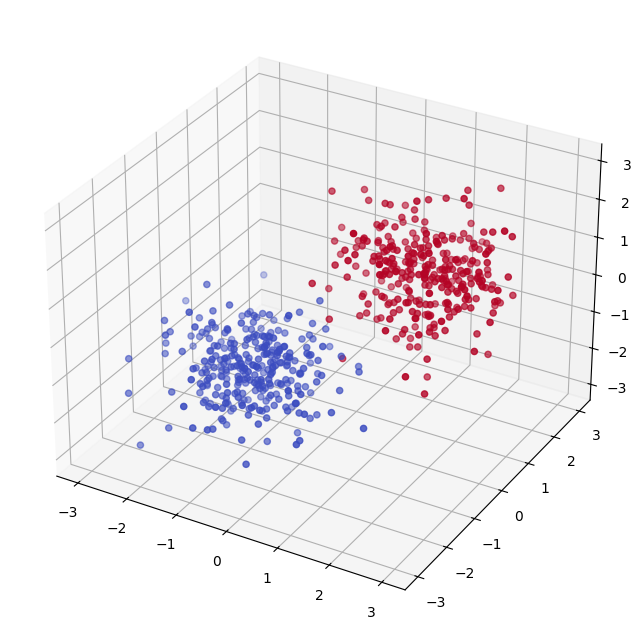

In [4]:
# Plot the dataset in 3D, with colours according to the class label

fig = plt.figure(figsize=(8, 10)) # set the size to 8x8
ax = fig.add_subplot(111, projection="3d")
ax.scatter(X1[:,0], X1[:,1], X1[:,2], c=y1, cmap="coolwarm") # changed the colour map because why not

plt.show()
plt.close(fig)

Dataset 2 - Circles 2D

In [5]:
# Use pandas to read the CSV file as a dataframe
df2 = pd.read_csv("circles500.csv")

# The y values are those labelled 'Class': extract their values
y2 = df2['Class'].values

# The x values are all other columns
del df2['Class']   # drop the 'Class' column from the dataframe
X2 = df2.values     # convert the remaining columns to a numpy array

In [6]:
# Check its dimensions

print(f"The dimensions of Dataset 2 are: {np.shape(X2)}")

The dimensions of Dataset 2 are: (500, 2)


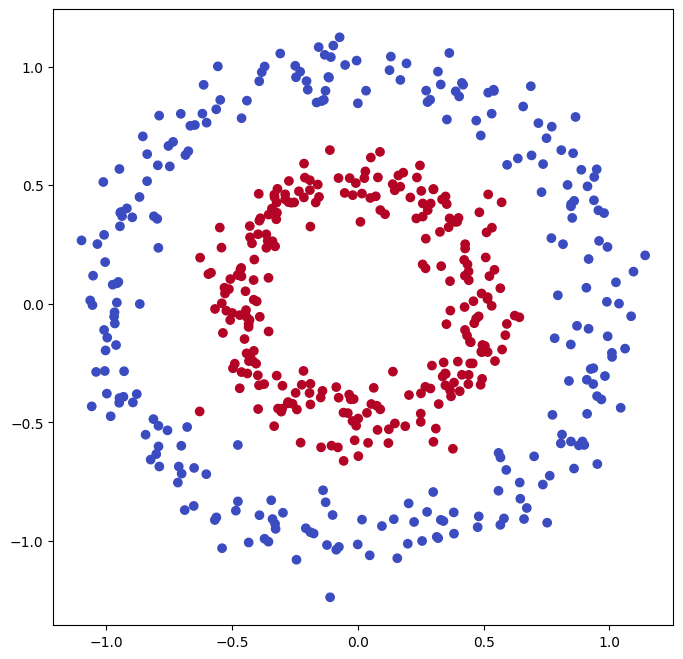

In [7]:
# plot X[0] vs X[1] and colour points according to the class, y

fig, ax = plt.subplots(figsize=(8, 8))

ax.scatter(X2[:,0], X2[:,1], c=y2, cmap="coolwarm")

plt.show()
plt.close(fig)

Examine Data

In [8]:
# Some examples of working with the data, to look at rows/columns
print ("len(X2):", len(X2))            # outer array: one per sample
print ("len(X2[0]):", len(X2[0]))      # each inner array is the attributes of one sample
print ("len(X2[:,0]):", len(X2[:,0]))  # select column 0 from array

# np.shape returns all dimensions of the array
(nsamples, nattribs) = np.shape(X2)
print ("X2: nsamples =", nsamples, ", nattribs =", nattribs)

# Now example the y vector (1D array)
print ("len(y2)", len(y2))
print ("np.shape(y2):", np.shape(y2))

# You can transpose the y data using 'reshape'
yt = np.reshape(y2, (len(y2),1))
print ("np.shape(yt):", np.shape(yt))
(nsamples, nattribs) = np.shape(yt)
print ("y2 transpose: nsamples =", nsamples, ", nattribs =", nattribs)

len(X2): 500
len(X2[0]): 2
len(X2[:,0]): 500
X2: nsamples = 500 , nattribs = 2
len(y2) 500
np.shape(y2): (500,)
np.shape(yt): (500, 1)
y2 transpose: nsamples = 500 , nattribs = 1


 Logistic Regressions,
goal is to find best line through points . Linear Regression gives a value between -infinity and +infinity. Logistic Regression outputs a probability (0 to 1) using sigmoid.
Logistic Regression computes a linear score z(x) = w.x + b .We then apply sigmoid function to convert the score to a vlue between 0 and 1. During training we update 'w' and 'b' using gradient descent to minimise the logloss between true label y and predicted output y^.

 After the training a hypothesis would get created which could be used for any future data samples in same format.

TASK 1
Setting the hyperparameters for the algorithm

In [9]:
alpha = 0.01#the learning rate
N=50#run N iterations. Compute the loss over N iterations.means you check loss / convergence every 50 updates.
max_iterations = 10000
threshold=0.0001#for convergence test, if loss is not changing much
stoppingg = False
J_running =0
J_running_prev =0
iteration =0
b=0.0
rng = np.random.default_rng(42)#just a random  seed to reproduce the results, random generator instance



Two function that would be used at each step/Row in the excel sheet  for the algorithm.


In [10]:
#defining the sigmoid activation fucntion and logloss functions used in logistic regression
def sigmoid(z):#We clip z to avoid overflow in exp(-z); sigmoid is saturated for large |z|.
  z = np.clip(z, -65, 65)
  return 1.0/(1.0 + np.exp(-z))


def logloss(ytrue,yhat):
  #Because the log-loss uses logarithms, log(0)=infinity.
  #Clip is small enough to not change learning, but big enough to prevent crashes.
  clip = 1e-11
  yhat = np.clip(yhat, clip, 1-clip)
  return -(ytrue*np.log(yhat) +(1-ytrue)*np.log(1-yhat))



In [11]:
loss = []
X=X1
y=y1
print(X.shape, y.shape)
features = X.shape[1] #in blobs 3 are there, inputing
w = rng.uniform(-0.01, 0.01, size=features) #initialising a weight vector of size  features/columns and i range of -0.01 to +0.01

while (not stoppingg) and (iteration < max_iterations):
  i = rng.integers(0, len(X) )#to pic a random row
  x = X[i]
  ytrue = y[i]

  z = float(np.dot(w,x) +b)
  yhat = float(sigmoid(z))

  #Calculate loss between actaul y from shett and yhat fom function
  J_current = float(logloss(ytrue,yhat))

  err = yhat - ytrue
  dw = err * x
  db = err

  #updating
  w= w-alpha*dw
  b=b-alpha*db

  #bookkeeping
  iteration+=1
  J_running += J_current


  if iteration%N == 0:#Check at every N iterations or epochs
    avgloss = J_running / N
    loss.append(avgloss)

    improvement = J_running_prev - avgloss
    J_running_prev = avgloss
    J_running = 0.0

    if improvement >=0 and improvement < threshold:
      stoppingg= True
      print("Stopped at iteration",iteration)





(600, 3) (600,)


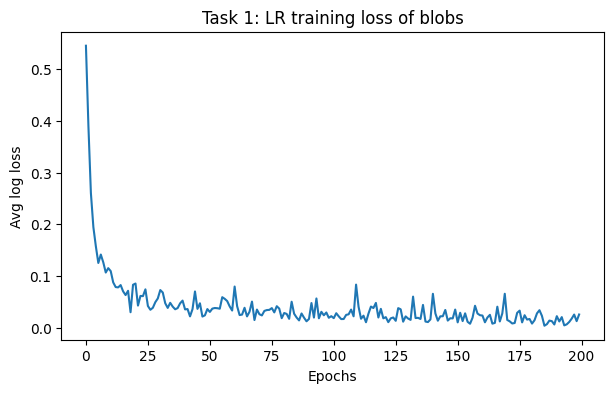

Training accuracy: 0.995


In [12]:
plt.figure(figsize=(7,4))
plt.plot(loss)
plt.xlabel("Epochs")
plt.ylabel("Avg log loss")
plt.title("Task 1: LR training loss of blobs")
plt.show()

y_prob = sigmoid(X @ w + b)
y_pred = (y_prob >= 0.5).astype(int)
print("Training accuracy:", np.mean(y_pred == y))

# TASK 2
Dividing each dataset blobs and circles to train/evalutaion and testing blocks. Normaly/According to the instructions training will be 70% of the dataset and evaluation , testing will be 15% respectively. So I define a function for it so that different dataset could use it.

In [13]:
def traintestevalsplit(X, y, seed=42):#we use a seed to shuffle indices so that train/eval/test split is random and could be reproduced.
  #we  must spit datset whie keeping the x values/features aligned with the ouput values/labels.

  gen = np.random.default_rng(seed)#creating a reproducible random generator
  indexlist = np.arange(len(X))
  gen.shuffle(indexlist)#using the reproducible random generator to shuffle the list, so it stays the same everytime
  X= X[indexlist]
  y = y[indexlist] # here same indexlist is used for rows, so each set of features will be mapped as t was in the dataset. Just the row ordering changes.
  noofrows = len(X)

  size = len(X)
  trainingsetsize = int(0.7*size)
  evaluationandtestsetsize = int(0.15*size)

  Xtrain, Ytrain = X[:trainingsetsize], y[:trainingsetsize]
  Xeval, Yeval = X[trainingsetsize:trainingsetsize+evaluationandtestsetsize], y[trainingsetsize:trainingsetsize+evaluationandtestsetsize]
  Xtest, Ytest = X[trainingsetsize+evaluationandtestsetsize:], y[trainingsetsize+evaluationandtestsetsize:]
  return Xtrain, Ytrain, Xeval, Yeval, Xtest, Ytest


In [14]:
Xtrain, Ytrain, Xeval, Yeval, Xtest, Ytest = traintestevalsplit(X1, y1, seed=42)
print(Xtrain.shape, Xeval.shape, Xtest.shape)

(420, 3) (90, 3) (90, 3)


In [15]:
stoppingg = False
J_running =0
J_running_prev =0
iteration =0
b=0.0
loss = []
X=Xtrain
y=Ytrain
print(X.shape, y.shape)
features = X.shape[1] #in blobs 3 are there, inputing
w = rng.uniform(-0.01, 0.01, size=features) #initialising a weight vector of size  features/columns and i range of -0.01 to +0.01

while (not stoppingg) and (iteration < max_iterations):
  i = rng.integers(0, len(X) )#to pic a random row
  x = X[i]
  ytrue = y[i]

  z = float(np.dot(w,x) +b)
  yhat = float(sigmoid(z))

  #Calculate loss between actaul y from shett and yhat fom function
  J_current = float(logloss(ytrue,yhat))

  err = yhat - ytrue
  dw = err * x
  db = err

  #updating
  w= w-alpha*dw
  b=b-alpha*db

  #bookkeeping
  iteration+=1
  J_running += J_current


  if iteration%N == 0:#Check at every N iterations or epochs
    avgloss = J_running / N
    loss.append(avgloss)

    improvement = J_running_prev - avgloss
    J_running_prev = avgloss
    J_running = 0.0

    if improvement >=0 and improvement < threshold:
      stoppingg= True
      print("Stopped at iteartion",iteration)

(420, 3) (420,)


In [16]:
def predictclass(X, w, b):
    return (sigmoid(X @ w + b) >= 0.5).astype(int)

trainpred = predictclass(Xtrain, w, b)
print("Train accuracy:", np.mean(trainpred == Ytrain))

Train accuracy: 0.9952380952380953


So the model is trained on the training set. In evaluation/tuning we do not change the values of w and b. Maybe we change the values of alpha,threshold i.e other paameters.
Till now training done.

In [17]:
evalpred = predictclass(Xeval, w, b)
print("Eval accuracy:", np.mean(evalpred == Yeval))

Eval accuracy: 1.0


Validation accuracy is already high for blobs. So we keep alpha , learning rate the same.

In [18]:
testpred = predictclass(Xtest, w, b)
print("TEst accuracy:", np.mean(testpred == Ytest))

TEst accuracy: 1.0


Here on test data we get accuracy of 1 which means the model does its job, generalises well for this dataset or application.

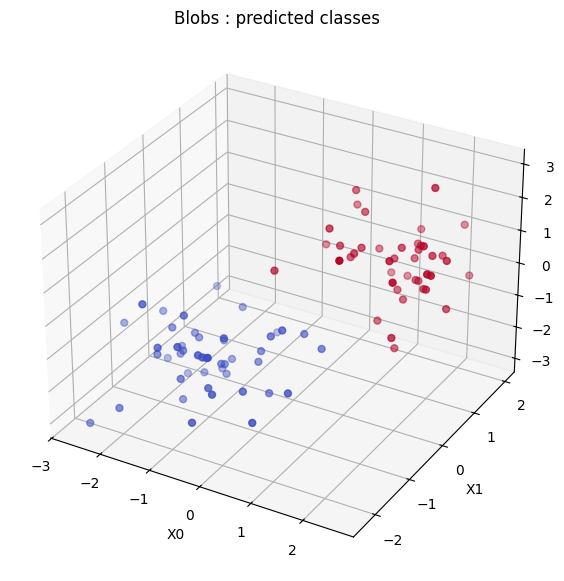

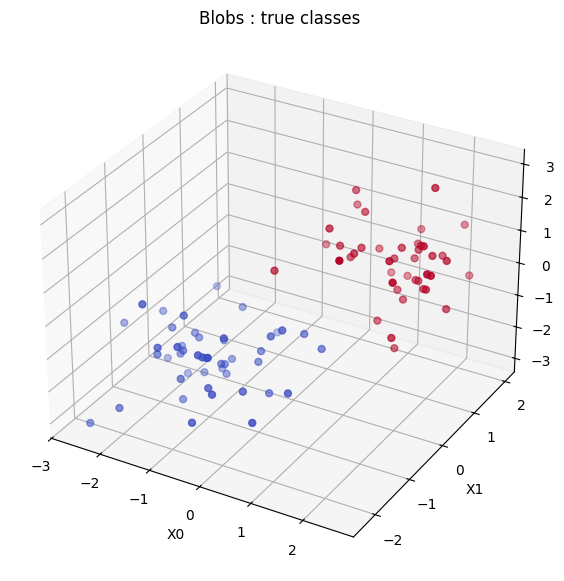

In [19]:
fig = plt.figure(figsize=(8,7))
ax = fig.add_subplot(111, projection="3d")
ypred = predictclass(Xtest, w, b)
ax.scatter(Xtest[:,0], Xtest[:,1], Xtest[:,2], c=ypred, cmap="coolwarm", s=25)
ax.set_title("Blobs : predicted classes ")
ax.set_xlabel("X0"); ax.set_ylabel("X1"); ax.set_zlabel("X2")
plt.show()
plt.close(fig)
fig = plt.figure(figsize=(8,7))
ax = fig.add_subplot(111, projection="3d")
ax.scatter(Xtest[:,0], Xtest[:,1], Xtest[:,2], c=Ytest, cmap="coolwarm", s=25)
ax.set_title("Blobs : true classes")
ax.set_xlabel("X0"); ax.set_ylabel("X1"); ax.set_zlabel("X2")
plt.show()
plt.close(fig)

Now doing the same for Circle dataset.

In [20]:
Xtrain, Ytrain, Xeval, Yeval, Xtest, Ytest = traintestevalsplit(X2, y2, seed=42)
print(Xtrain.shape, Xeval.shape, Xtest.shape)

(350, 2) (75, 2) (75, 2)


In [21]:
stoppingg = False
J_running =0
J_running_prev =0
iteration =0
b=0.0
loss = []
X=Xtrain
y=Ytrain
print(X.shape, y.shape)
features = X.shape[1] #in blobs 3 are there, inputing
w = rng.uniform(-0.01, 0.01, size=features) #initialising a weight vector of size  features/columns and i range of -0.01 to +0.01

while (not stoppingg) and (iteration < max_iterations):
  i = rng.integers(0, len(X) )#to pic a random row
  x = X[i]
  ytrue = y[i]

  z = float(np.dot(w,x) +b)
  yhat = float(sigmoid(z))

  #Calculate loss between actaul y from shett and yhat fom function
  J_current = float(logloss(ytrue,yhat))

  err = yhat - ytrue
  dw = err * x
  db = err

  #updating
  w= w-alpha*dw
  b=b-alpha*db

  #bookkeeping
  iteration+=1
  J_running += J_current


  if iteration%N == 0:#Check at every N iterations or epochs
    avgloss = J_running / N
    loss.append(avgloss)

    improvement = J_running_prev - avgloss
    J_running_prev = avgloss
    J_running = 0.0

    if improvement >=0 and improvement < threshold:
      stoppingg= True
      print("Stopped at iteartion",iteration)

(350, 2) (350,)


In [22]:
def predictclass(X, w, b):
    return (sigmoid(X @ w + b) >= 0.5).astype(int)

trainpred = predictclass(Xtrain, w, b)
print("Train accuracy:", np.mean(trainpred == Ytrain))

Train accuracy: 0.5142857142857142


In [23]:
evalpred = predictclass(Xeval, w, b)
print("Eval accuracy:", np.mean(evalpred == Yeval))
testpred = predictclass(Xtest, w, b)
print("Test accuracy:", np.mean(testpred == Ytest))

Eval accuracy: 0.4666666666666667
Test accuracy: 0.4666666666666667


This is normal for a linear classifier. The circle dataset needs  a non-linear classifier. We try to tune in the learning rate.


In [24]:
def predictclass(X, w, b):
    return (sigmoid(X @ w + b) >= 0.5).astype(int)

alphas = [0.5, 0.1, 0.01, 0.001]
bestalpha, bestval = None, -1
bestwb = None

for a in alphas:
  
    stoppingg = False
    iteration = 0
    J_running = 0.0
    J_running_prev =     b = 0.0
    loss = []

    X = Xtrain
    y = Ytrain
    features = X.shape[1]
    w = rng.uniform(-0.01, 0.01, size=features)

    while (not stoppingg) and (iteration < max_iterations):
        i = rng.integers(0, len(X))
        x = X[i]
        ytrue = y[i]

        z = float(np.dot(w, x) + b)
        yhat = float(sigmoid(z))
        J_current = float(logloss(ytrue, yhat))

        err = yhat - ytrue
        dw = err * x
        db = err

        w = w - a * dw
        b = b - a * db

        iteration += 1
        J_running += J_current

        if iteration % N == 0:
            avgloss = J_running / N
            improvement = J_running_prev - avgloss
            J_running_prev = avgloss
            J_running = 0.0

            if improvement >= 0 and improvement < threshold:
                stoppingg = True

    # evaluate
    trainacc = np.mean(predictclass(Xtrain, w, b) == Ytrain)
    valacc   = np.mean(predictclass(Xeval,  w, b) == Yeval)
    print(f"alpha={a:<6} train_acc={trainacc:.3f}  val_acc={valacc:.3f}")

    if valacc > bestval:
        bestval = valacc
        bestalpha = a
        bestwb = (w, b)

print("\nBest alpha for circles:", bestalpha, "val_acc:", bestval)

alpha=0.5    train_acc=0.549  val_acc=0.493
alpha=0.1    train_acc=0.629  val_acc=0.653
alpha=0.01   train_acc=0.514  val_acc=0.467
alpha=0.001  train_acc=0.514  val_acc=0.467

Best alpha for circles: 0.1 val_acc: 0.6533333333333333


In [25]:
wbest, bbest = bestwb   # from above we got the params

testpred = predictclass(Xtest, wbest, bbest)
testacc  = np.mean(testpred == Ytest)

print("Test accuracy:", testacc)

Test accuracy: 0.6


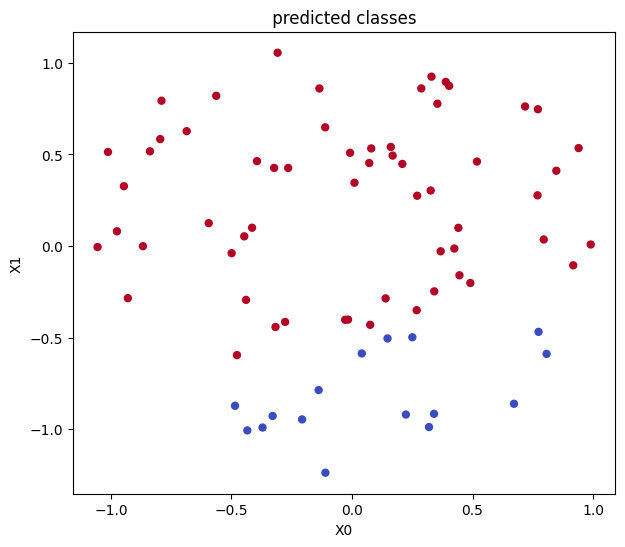

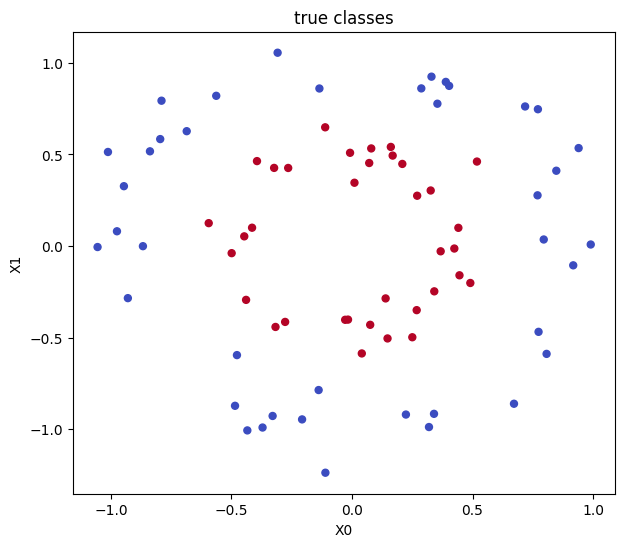

In [26]:
plt.figure(figsize=(7,6))
plt.scatter(Xtest[:,0], Xtest[:,1], c=testpred, cmap="coolwarm", s=25)
plt.title(" predicted classes ")
plt.xlabel("X0"); plt.ylabel("X1")
plt.show()

plt.figure(figsize=(7,6))
plt.scatter(Xtest[:,0], Xtest[:,1], c=Ytest, cmap="coolwarm", s=25)
plt.title("true classes")
plt.xlabel("X0"); plt.ylabel("X1")
plt.show()

 We fine tuned the alpha parameter to increase the accuracy from 0.4 to 0.6. Blobs dataset were lineraly separable so we got more accuracy. As you could see for circle dataset a linear plae do fail to classify.

# TASK 3
Now we have to create a shallow network with 1 hidden layer and one output node. We could use the same dataset as before but we could vary the no of nodes in the hidden layer.


This function is ffor initialising the weights and biases from 'input to hidden' and hidden to output. We only require one output node so bias of that is a single value not a vector. We must keep a bias ther becoz 'yhat=z2=a1.w2+b2'. Its part of formula.

In [27]:
def initnn(ninput, nhidden, seed=42):
    rng = np.random.default_rng(seed)
    W1 = rng.uniform(-0.01, 0.01, size=(nhidden, ninput))
    b1 = np.zeros(nhidden)
    W2 = rng.uniform(-0.01, 0.01, size=nhidden)
    b2 = 0.0
    return W1, b1, W2, b2


tanh activation function is used in hidden layers. It lets the network learn non-linear features. But at the output layer/node we just classify to 0 or 1. Sigmoid is used for that.tanh gives values in range -1 to +1.

In [28]:
def tanh(z):
    return np.tanh(z)

This is the function where forward propogation logic happens according to algorithm.
z = w@x +b. Then activation done on it.
yhat=activation(z)=sigmoid(z) or tan(z)

In [29]:
def forwardpass(x, W1, b1, W2, b2):
    z1 = W1 @ x + b1
    a1 = tanh(z1)
    z2 = W2 @ a1 + b2
    yhat = sigmoid(z2)
    return z1, a1, z2, yhat

In [30]:
def predictnn(X, W1, b1, W2, b2):

    z1 = X@W1.T + b1
    a1 = tanh(z1)
    z2 = a1 @ W2 + b2
    return sigmoid(z2)

def predict(X, W1, b1, W2, b2):
    return (predictnn(X, W1, b1, W2, b2) >= 0.5).astype(int)#to return 0 or 1 , ie. is the class labels.

def accuracy(X, y, W1, b1, W2, b2):
    return float(np.mean(predict(X, W1, b1, W2, b2) == y))

In [31]:
def train(Xtrain, Ytrain,
                 nhidden, alpha,
                 maxiterations, N, threshold,
                 seed):
    rng = np.random.default_rng(seed)
    print(Xtrain.shape[1])
    nin = Xtrain.shape[1]
    W1, b1, W2, b2 = initnn(nin, nhidden, seed=seed)

    loss = []
    valacc = []

    stopping = False
    iteration = 0
    J_running = 0.0
    J_prev = 0.0

    while (not stopping) and (iteration < maxiterations):
        i = rng.integers(0, len(Xtrain))
        x = Xtrain[i]
        ytrue = Ytrain[i]

        # forward passing
        z1, a1, z2, yhat = forwardpass(x, W1, b1, W2, b2)

        #backpropogating
        J_current = float(logloss(ytrue, yhat))
        deltaout = (yhat - ytrue)


        dW2 = deltaout * a1
        db2 = deltaout

        #in hidden layer, the derivate formula
        deltah = (W2 * deltaout) * (1.0 - a1**2)


        dW1 = np.outer(deltah, x)#beacuase no of input not equal to no of nodes in hidden layer, So we cannot use @.
        db1 = deltah


        W2 -= alpha * dW2
        b2 -= alpha * db2
        W1 -= alpha * dW1
        b1 -= alpha * db1

        # bookkeeping
        iteration += 1
        J_running += J_current

        if iteration % N == 0:
            avgloss = J_running / N
            loss.append(avgloss)
            J_running = 0.0

            # early stopping check
            improvement = J_prev - avgloss
            J_prev = avgloss
            if improvement >= 0 and improvement < threshold:
                stopping = True



    params = (W1, b1, W2, b2)

    return params

In [32]:
def task3(X, y, hiddenweights=(8,16,32,64,128,256,512,1024,2048),
                          alpha=(0.1, 0.05, 0.01, 0.001, 0.0001, 0.2, 0.02, 0.002, 0.0002, 0.3, 0.03, 0.003, 0.0003),
                          seed=42):

    Xtrain, Ytrain, Xeval, Yeval, Xtest, Ytest = traintestevalsplit(X, y, seed=seed)

    best = None

    for h in hiddenweights:
        for a in alpha:
            params = train(
                Xtrain, Ytrain,
                nhidden=h, alpha=a,
                maxiterations=20000, N=50, threshold=0.0001,
                seed=seed
            )
            W1, b1, W2, b2 = params
            trainacc = accuracy(Xtrain, Ytrain, W1, b1, W2, b2)
            valacc   = accuracy(Xeval, Yeval, W1, b1, W2, b2)
            print(f" hidden={h} alpha={a} trainining Accuracy={trainacc:.3f} Validation Accuracy={valacc:.3f}")

            if (best is None) or (valacc > best[0]):
                best = (valacc, h, a, params)

    bestvalacc, besth, besta, bestparams = best
    W1, b1, W2, b2 = bestparams


    testacc = accuracy(Xtest, Ytest, W1, b1, W2, b2)
    print(f"\n: BEST hidden={besth} alpha={besta} val_acc={bestvalacc:.3f} TEST acc={testacc:.3f}\n")

    return bestparams, (besth, besta, bestvalacc, testacc)




In [33]:
task3(X1, y1)

3
 hidden=8 alpha=0.1 trainining Accuracy=0.998 Validation Accuracy=0.989
3
 hidden=8 alpha=0.05 trainining Accuracy=0.995 Validation Accuracy=1.000
3
 hidden=8 alpha=0.01 trainining Accuracy=0.995 Validation Accuracy=1.000
3
 hidden=8 alpha=0.001 trainining Accuracy=0.971 Validation Accuracy=0.967
3
 hidden=8 alpha=0.0001 trainining Accuracy=0.690 Validation Accuracy=0.689
3
 hidden=8 alpha=0.2 trainining Accuracy=0.998 Validation Accuracy=0.989
3
 hidden=8 alpha=0.02 trainining Accuracy=0.995 Validation Accuracy=1.000
3
 hidden=8 alpha=0.002 trainining Accuracy=0.995 Validation Accuracy=1.000
3
 hidden=8 alpha=0.0002 trainining Accuracy=0.543 Validation Accuracy=0.600
3
 hidden=8 alpha=0.3 trainining Accuracy=0.995 Validation Accuracy=1.000
3
 hidden=8 alpha=0.03 trainining Accuracy=0.995 Validation Accuracy=1.000
3
 hidden=8 alpha=0.003 trainining Accuracy=0.995 Validation Accuracy=1.000
3
 hidden=8 alpha=0.0003 trainining Accuracy=0.486 Validation Accuracy=0.578
3
 hidden=16 alpha=

((array([[ 0.81523181,  0.56446056,  0.57212124],
         [-0.39535961, -0.30326427, -0.30018362],
         [ 0.36154809,  0.27214445,  0.27220008],
         [-0.6695264 , -0.48065434, -0.48098328],
         [-0.42117442, -0.30895228, -0.32710959],
         [-0.56271417, -0.40623787, -0.42332959],
         [ 0.82957234,  0.57428214,  0.57797817],
         [ 0.8588461 ,  0.59727363,  0.59767392]]),
  array([ 0.05390161, -0.03120669,  0.02744942, -0.04835092, -0.03267555,
         -0.04184013,  0.0544132 ,  0.05619493]),
  array([ 1.4866193 , -0.62555513,  0.55912586, -1.15499903, -0.66977398,
         -0.93893617,  1.52043211,  1.60315779]),
  np.float64(0.07245846970492244)),
 (8, 0.05, 1.0, 1.0))

In [34]:
task3(X2, y2)

2
 hidden=8 alpha=0.1 trainining Accuracy=0.514 Validation Accuracy=0.467
2
 hidden=8 alpha=0.05 trainining Accuracy=0.514 Validation Accuracy=0.467
2
 hidden=8 alpha=0.01 trainining Accuracy=0.486 Validation Accuracy=0.533
2
 hidden=8 alpha=0.001 trainining Accuracy=0.514 Validation Accuracy=0.467
2
 hidden=8 alpha=0.0001 trainining Accuracy=0.514 Validation Accuracy=0.467
2
 hidden=8 alpha=0.2 trainining Accuracy=0.486 Validation Accuracy=0.533
2
 hidden=8 alpha=0.02 trainining Accuracy=0.514 Validation Accuracy=0.467
2
 hidden=8 alpha=0.002 trainining Accuracy=0.486 Validation Accuracy=0.533
2
 hidden=8 alpha=0.0002 trainining Accuracy=0.514 Validation Accuracy=0.467
2
 hidden=8 alpha=0.3 trainining Accuracy=0.514 Validation Accuracy=0.467
2
 hidden=8 alpha=0.03 trainining Accuracy=0.514 Validation Accuracy=0.467
2
 hidden=8 alpha=0.003 trainining Accuracy=0.514 Validation Accuracy=0.467
2
 hidden=8 alpha=0.0003 trainining Accuracy=0.514 Validation Accuracy=0.467
2
 hidden=16 alpha=

((array([[ 0.0054779 , -0.00122238],
         [ 0.00717033,  0.00394743],
         [-0.00811895,  0.00951254],
         ...,
         [-0.00797638,  0.00529608],
         [ 0.00672383, -0.00627111],
         [-0.00561644, -0.00353578]], shape=(2048, 2)),
  array([ 3.62561777e-07,  4.84433094e-07,  7.42771307e-07, ...,
         -1.36717427e-06, -1.60764940e-06,  5.57663329e-07], shape=(2048,)),
  array([ 0.00181785,  0.00243123,  0.00374076, ..., -0.00686034,
         -0.00808707,  0.00280709], shape=(2048,)),
  np.float64(0.00019881364327964588)),
 (2048, 0.0002, 0.64, 0.64))

The alpha rates and number of hudden nodes were varied to get test accuracy better for circles dataset. By adjusting the number of hudden layer nodes and varying the learning(alpha) rate we could see an increase from 0.6 to 0.64. So with different parameter settings accuracy could be improved. That is why neural network are a better choice compared to LR.

# TASK4
Here we are doing a image classification problem. Emnist Letters is a collection of handwritten alphabet images.

Proffessor assigned to letters to us 'H' and 'Y'. 'H' an 'Y' already has the label 8 and 25. But we dont know any function that could predict values between 8 and 25. Sigmoid could be also since its a binary classification.

In [35]:


# Loading the dataset- https://www.youtube.com/watch?v=tEUW7hjcsqo

data = np.load("emnist_letters_85800.npz")
print(data.files)
#print(data.dim())
x = data["x"]#x are the iamges
y = data["y"]#y are the labels
print(x.shape)#so total 85800 images of 28*28 pixel size, they are grey scale 1
print(y.shape)#so one label per that image


['x', 'y']
(85800, 28, 28, 1)
(85800,)


In [36]:
#we done want info if its grey scale, so removing that field
x=x.squeeze(-1) #https://numpy.org/doc/1.25/reference/generated/numpy.squeeze.html?utm_source=chatgpt.com
print(x.shape)

(85800, 28, 28)


In [37]:
#we know labels of H is 8 and Y is 25
Hlabel =8
Ylabel = 25
z = (y == Hlabel) | (y == Ylabel) #no loop is needed , numpy operation
H = x[z]
Y = y[z]
print(H.shape, Y.shape)#therfore only 6600 images from total are H or Y

(6600, 28, 28) (6600,)


In [38]:
totaly=np.sum(Y==Ylabel)
print(totaly)
totalx=np.sum(Y==Hlabel)
print(totalx)
#Contains equal number of H an Y.

3300
3300


In [39]:
#now we nedd to convert this two a binary classification problem
#Let H be assigned 0 and Y be 1

binaryvector = (Y == Ylabel).astype(int)
print(binaryvector.shape)#So this Binary vector all 0 are H and 1 is Y


(6600,)


In [40]:
#Training data cannot be high dimensional like this
#We could do flattening of images flattening keeps all the pixel values just changes its arrangement
#also normaklisation is done before training as a standard
Hflat = H.reshape(H.shape[0], -1).astype(np.float64)
print(Hflat.shape)
Hflat.max()


(6600, 784)


np.float64(1.0)

So we converted the input and output of training algorithm such a way that they coud be used in our NN Algorithm.

In [41]:
Xtrain, Ytrain, Xeval, Yeval, Xtest, Ytest = traintestevalsplit(Hflat, binaryvector, seed=42)
print(Xtrain.shape,Xeval.shape,Xtest.shape)
print(Ytrain.shape,Yeval.shape,Ytest.shape)


(4620, 784) (990, 784) (990, 784)
(4620,) (990,) (990,)


The dataset was perfect for 70,15,15 split for the letters provided

In [42]:
#setting the hyperparameters
alpha = 0.01
maxiterations = 20000
N = 50
threshold = 0.0001
seed = 42


In [43]:
def train4(Xtrain, Ytrain,
                nhidden, alpha,
                maxiterations, N, threshold,
                seed=42):

    rng = np.random.default_rng(seed)
    nin = Xtrain.shape[1]
    W1, b1, W2, b2 = initnn(nin, nhidden, seed=seed)

    loss4=[]


    stopping = False
    iteration = 0
    J_running = 0.0
    J_prev = 0.0

    while (not stopping) and (iteration < maxiterations):
        i = rng.integers(0, len(Xtrain))
        x = Xtrain[i]
        ytrue = Ytrain[i]

        # forward
        z1, a1, z2, yhat = forwardpass(x, W1, b1, W2, b2)

        # loss
        J_current = float(logloss(ytrue, yhat))

        # backprop (same math as Task 3)
        deltaout = (yhat - ytrue)
        dW2 = deltaout * a1
        db2 = deltaout

        deltah = (W2 * deltaout) * (1.0 - a1**2)   # tanh' = (1 - a1^2)
        dW1 = np.outer(deltah, x)
        db1 = deltah

        # update
        W2 -= alpha * dW2
        b2 -= alpha * db2
        W1 -= alpha * dW1
        b1 -= alpha * db1

        # bookkeeping
        iteration += 1
        J_running += J_current

        if iteration % N == 0:
            avgloss = J_running / N
            loss4.append(avgloss)
            J_running = 0.0



            improvement = J_prev - avgloss
            J_prev = avgloss
            if improvement >= 0 and improvement < threshold:
                stopping = True

    params = (W1, b1, W2, b2)

    return params



In [44]:



def task4(X, y,
          hiddenweights,
          alpha,
          seed=42):

    Xtrain, Ytrain, Xeval, Yeval, Xtest, Ytest = traintestevalsplit(X, y, seed=seed)
    #print("hi")
    best = None

    for h in hiddenweights:
        for a in alpha:
            params = train4(
                Xtrain, Ytrain,
                nhidden=h, alpha=a,
                maxiterations=20000, N=200, threshold=0.0001,
                seed=seed
            )
            W1, b1, W2, b2 = params

            trainacc = accuracy(Xtrain, Ytrain, W1, b1, W2, b2)
            valacc   = accuracy(Xeval,  Yeval,  W1, b1, W2, b2)
            print(f" hidden={h} alpha={a} train_acc={trainacc:.3f} val_acc={valacc:.3f}")

            if (best is None) or (valacc > best[0]):
                best = (valacc, h, a, params)

    bestvalacc, besth, besta, bestparams= best
    W1, b1, W2, b2 = bestparams

    testacc = accuracy(Xtest, Ytest, W1, b1, W2, b2)
    print(f"\n BEST hidden={besth} alpha={besta} val_acc={bestvalacc:.3f} TEST acc={testacc:.3f}\n")

    return bestparams,  (besth, besta, bestvalacc, testacc)






In [45]:
bestparams, bestresult = task4(
    Hflat, binaryvector,
    hiddenweights=(16, 32, 64, 128, 256),
    alpha=(0.1, 0.05, 0.01, 0.005, 0.001),
    seed=42
)

print("Best result tuple:", bestresult)

 hidden=16 alpha=0.1 train_acc=0.986 val_acc=0.979
 hidden=16 alpha=0.05 train_acc=0.994 val_acc=0.985
 hidden=16 alpha=0.01 train_acc=0.987 val_acc=0.979
 hidden=16 alpha=0.005 train_acc=0.981 val_acc=0.976
 hidden=16 alpha=0.001 train_acc=0.974 val_acc=0.973
 hidden=32 alpha=0.1 train_acc=0.989 val_acc=0.979
 hidden=32 alpha=0.05 train_acc=0.988 val_acc=0.982
 hidden=32 alpha=0.01 train_acc=0.985 val_acc=0.980
 hidden=32 alpha=0.005 train_acc=0.983 val_acc=0.981
 hidden=32 alpha=0.001 train_acc=0.974 val_acc=0.973
 hidden=64 alpha=0.1 train_acc=0.990 val_acc=0.984
 hidden=64 alpha=0.05 train_acc=0.993 val_acc=0.986
 hidden=64 alpha=0.01 train_acc=0.985 val_acc=0.979
 hidden=64 alpha=0.005 train_acc=0.982 val_acc=0.980
 hidden=64 alpha=0.001 train_acc=0.974 val_acc=0.973
 hidden=128 alpha=0.1 train_acc=0.991 val_acc=0.983
 hidden=128 alpha=0.05 train_acc=0.989 val_acc=0.987
 hidden=128 alpha=0.01 train_acc=0.981 val_acc=0.973
 hidden=128 alpha=0.005 train_acc=0.982 val_acc=0.979
 hidd

Best accuray we achieve is 0.980

TASK 5
Here we need to increase the model capacity, That is to make no of hidden layers more with varying number of nodes in them. We could see if we get an increase in accuracy but this is with an added cost of computation.

In [46]:

def tanhderivative(a):#In Task only one hidden layer was there, so we had computed the derivative in the taskitself without a function
    
    return 1.0 - a**2

In [47]:
def initdeep(layers, seed=42):
    
    rng = np.random.default_rng(seed)
    Ws, bs = [], []
    for l in range(len(layers) - 1):
        hlayerin = layers[l]
        hlayerout = layers[l+1]
        W = rng.uniform(-0.01, 0.01, size=(hlayerout, hlayerin))#this are the weightvectors between layers
        b = np.zeros(hlayerout)#creating one bias per neuron in layers
        Ws.append(W)#list containing the weights for the full network depending on the architecture
        bs.append(b)#list of all biases in network
    return Ws, bs

In [48]:

def forwarddeep(x, Ws, bs):
  
    a = x#we assign like this because to avoid naming confusion
    alist = [a]   # input
    zlist = []    # z for each layer

    L = len(Ws)
    for l in range(L):
        z = Ws[l] @ a + bs[l]
        zlist.append(z)

        if l < L - 1:
            a = np.tanh(z)
        else:
            a = sigmoid(z)   # final output should be a propability
        alist.append(a)

    return zlist, alist

In [49]:

def backwarddeep(ytrue, zlist, alist, Ws, l2lambda):
    
    L = len(Ws)
    dWs = [None] * L
    dbs = [None] * L

    
    yhat = alist[-1]
    yhatscalar = float(np.ravel(yhat)[0])
    delta = (yhatscalar - float(ytrue))  # scalar

    for l in reversed(range(L)):
        aprev = alist[l]  # activation from previous layer

        if l == L - 1:
            dW = delta * aprev
            db = delta
        else:
            # hidden layer: delta is a vector, jhave to do vector operations
            z = zlist[l]
            a = alist[l+1]  # tanh(z) activation function for hidden layers
            dW = np.outer(delta, aprev)
            db = delta
        if l2lambda > 0.0: #used to avoid overfitting, only regularising the weights in the netwrok
            #bias is not regularised coz "you are forcing neurons to have less freedom to shift boundaries"
            #Simply it makes the training worse
            dW = dW + l2lambda * Ws[l]

        dWs[l] = dW
        dbs[l] = db

        if l > 0:
            # If current delta is scalar, W.T @ delta gives vector; if vector, gives vector.
            deltavector = Ws[l].T @ np.atleast_1d(delta)
            # previous layer activation is a_list[l] (tanh output)
            apreviouslayer = np.atleast_1d(alist[l])
            delta = deltavector * tanhderivative(apreviouslayer)

    return dWs, dbs


In [50]:
def predictprobdeep(X, Ws, bs):
    probs = np.zeros(len(X))
    for i in range(len(X)):
        zlist, alist = forwarddeep(X[i], Ws, bs)
        probs[i] = float(np.ravel(alist[-1])[0])
    return probs


def predictclassdeep(X, Ws, bs, threshold=0.5):
    return (predictprobdeep(X, Ws, bs) >= threshold).astype(int)


def accuracydeep(X, y, Ws, bs):
    return float(np.mean(predictclassdeep(X, Ws, bs) == y))

In [51]:
def train5(Xtrain, Ytrain,
           layers, alpha,
           maxiterations, N, threshold,
           l2lambda,
           seed=42):
  
    rng = np.random.default_rng(seed)
    Ws, bs = initdeep(layers, seed=seed)

    losscurve = []
    stopping = False
    iteration = 0
    J_running = 0.0
    J_prev = 0.0

    while (not stopping) and (iteration < maxiterations):
        i = rng.integers(0, len(Xtrain))
        x = Xtrain[i]
        ytrue = Ytrain[i]

        # forward
        zlist, alist = forwarddeep(x, Ws, bs)
        yhat = float(np.ravel(alist[-1])[0])
        J_current = float(logloss(ytrue, yhat))

        # to reflect L2 penalty
        if l2lambda > 0.0:
            l2pen = 0.5 * l2lambda * sum(np.sum(W*W) for W in Ws)
            J_current = J_current + l2pen

        # backward
        dWs, dbs = backwarddeep(ytrue, zlist, alist, Ws, l2lambda=l2lambda)

        # update
        for l in range(len(Ws)):
            Ws[l] -= alpha * dWs[l]
            bs[l] -= alpha * np.atleast_1d(dbs[l])

        # bookkeeping
        iteration += 1
        J_running += J_current

        if iteration % N == 0:
            avgloss = J_running / N
            losscurve.append(avgloss)
            J_running = 0.0

            improvement = J_prev - avgloss
            J_prev = avgloss
            if improvement >= 0 and improvement < threshold:
                stopping = True

    return (Ws, bs), losscurve



https://medium.com/analytics-vidhya/regularization-understanding-l1-and-l2-regularization-for-deep-learning-a7b9e4a409bf

L2 regularisationwas used here to avoid overfitting . It was also mentioned in the lecture and also in the slides.

In [52]:





def task5(X, y,
              architectures,
              alphas=(0.05, 0.01, 0.005),
              l2lambdas=(0.0, 0.001, 0.0001, 0.00001),
              seed=42):
   
    Xtrain, Ytrain, Xeval, Yeval, Xtest, Ytest = traintestevalsplit(X, y, seed=seed)

    best = None  # (valacc, arch, alpha, l2, params, loss_curve)

    for arch in architectures:
        for a in alphas:
            for l2 in l2lambdas:
                (Ws, bs), losscurve = train5(
                    Xtrain, Ytrain,
                    layers=arch, alpha=a,
                    maxiterations=30000, N=50, threshold=1e-4,
                    l2lambda=l2,
                    seed=seed
                )

                trainacc = accuracydeep(Xtrain, Ytrain, Ws, bs)
                valacc   = accuracydeep(Xeval,  Yeval,  Ws, bs)

                print(f"arch={arch} alpha={a:<6} l2={l2:<7} train_acc={trainacc:.3f} val_acc={valacc:.3f}")

                if (best is None) or (valacc > best[0]):
                    best = (valacc, arch, a, l2, (Ws, bs), losscurve)

    bestval, bestarch, besta, bestl2, bestparams, bestcurve = best
    Ws, bs = bestparams
    testacc = accuracydeep(Xtest, Ytest, Ws, bs)

    print("\nBEST SETTINGS")
    print(f"arch={bestarch}")
    print(f"alpha={besta}")
    print(f"lambda={bestl2}")
    print(f"val accuracy={bestval:.3f}")
    print(f"test accuracy={testacc:.3f}\n")

    return (Ws, bs), bestcurve, (bestarch, besta, bestl2, bestval, testacc), (Xtrain, Ytrain, Xeval, Yeval, Xtest, Ytest)


In [ ]:
# X4, y4 should be your Task 4 dataset (ONLY the two classes you were assigned),
# flattened to (n_samples, 784), labels 0/1.
X4 = Hflat
y4 = binaryvector

architectures = [ #defined a list of list, of a possible architecture of network
    [X4.shape[1], 64, 1],            
    [X4.shape[1], 128, 64, 1],       
    [X4.shape[1], 256, 128, 64,32, 1]  
]

bestparams, losscurve, bestinfo, splits = task5(
    X4, y4,
    architectures=architectures,
    alphas=(0.05, 0.06, 0.0456, 0.01, 0.02, 0.03, 0.3, 0.2),#best for previous ws around 0.5
    l2lambdas=(0.0, 0.001, 0.0001, 0.00001,0.000001),#L2 regularisation params values
    #to big lambda may underfit, too small may not reduce overfitting enough
    seed=42
)

# Plotting training curve for the best run
import matplotlib.pyplot as plt
plt.figure(figsize=(7,4))
plt.plot(losscurve)
plt.xlabel("Epoch blocks")
plt.ylabel("Avg loss")
plt.title("Task 5: Deep NN training curve of the best parameters")
plt.show()


arch=[784, 64, 1] alpha=0.05   l2=0.0     train_acc=0.987 val_acc=0.982
arch=[784, 64, 1] alpha=0.05   l2=0.001   train_acc=0.991 val_acc=0.980
arch=[784, 64, 1] alpha=0.05   l2=0.0001  train_acc=0.990 val_acc=0.982
arch=[784, 64, 1] alpha=0.05   l2=1e-05   train_acc=0.990 val_acc=0.978
arch=[784, 64, 1] alpha=0.05   l2=1e-06   train_acc=0.991 val_acc=0.985
arch=[784, 64, 1] alpha=0.06   l2=0.0     train_acc=0.990 val_acc=0.981
arch=[784, 64, 1] alpha=0.06   l2=0.001   train_acc=0.990 val_acc=0.987
arch=[784, 64, 1] alpha=0.06   l2=0.0001  train_acc=0.989 val_acc=0.981
arch=[784, 64, 1] alpha=0.06   l2=1e-05   train_acc=0.993 val_acc=0.981
arch=[784, 64, 1] alpha=0.06   l2=1e-06   train_acc=0.991 val_acc=0.979
arch=[784, 64, 1] alpha=0.0456 l2=0.0     train_acc=0.994 val_acc=0.984
arch=[784, 64, 1] alpha=0.0456 l2=0.001   train_acc=0.985 val_acc=0.981
arch=[784, 64, 1] alpha=0.0456 l2=0.0001  train_acc=0.995 val_acc=0.986
arch=[784, 64, 1] alpha=0.0456 l2=1e-05   train_acc=0.995 val_ac

We couldnot see an improvement with the list of parameters given for task5. If we vary the architecture, the no of nodes in each layer and the alpha and l2param values. It would most probably improve.